In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%load_ext rpy2.ipython

In [55]:
iris = sns.load_dataset("iris")
df = pd.DataFrame(iris)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [54]:
%%R

data(iris)
str(iris)

'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


# Frecuencias

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Text(0, 0.5, 'Frecuencia')

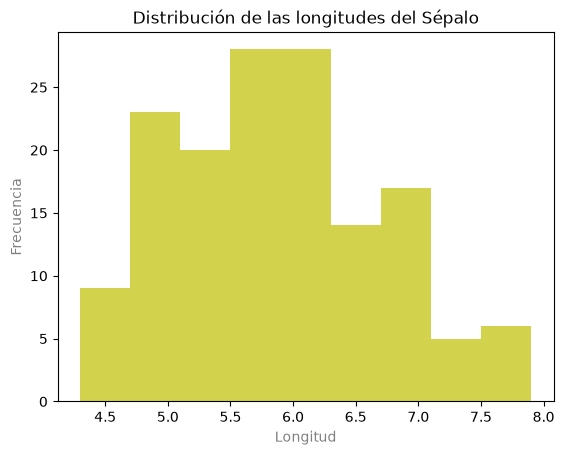

In [65]:
print(df["species"].value_counts())

plt.figure()
df['sepal_length'].plot.hist(alpha=0.7,  # Con alpha seteamos la transparencia
                     color='y',
                     bins=9,
                     title='Distribución de las longitudes del Sépalo')
plt.xlabel('Longitud', color='grey')
plt.ylabel('Frecuencia',color='grey')


    setosa versicolor  virginica 
  33.33333   33.33333   33.33333 
[1] 150


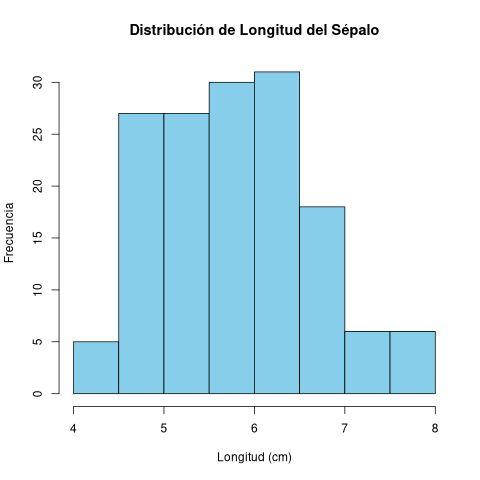

In [67]:
%%R

print(table(iris$Species)/length(iris$Species)*100)

hist(iris$Sepal.Length,
     main = "Distribución de Longitud del Sépalo", # Título
     xlab = "Longitud (cm)",                       # Etiqueta X
     ylab = "Frecuencia",                          # Etiqueta Y
     col = "skyblue",                              # Color de relleno
     border = "black",                             # Color del borde
     breaks = 9)                                   # Similar al 'bins' de Python

# Medidas de Tendencia

## Media

In [95]:
#axis 1(promedio de fila) 0(promedio de columna)
#skipna (saltar valores NA)
#numeric_only (usar solo las columnas o filas numéticas)
df.mean(axis=0, skipna=True, numeric_only=True)

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [100]:
%%R

#aplicar una funcion a varias columnas al tiempo (iris[filas, columnas], funcion)
sapply(iris[1:150, 1:4], mean)

Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
    5.843333     3.057333     3.758000     1.199333 


## Mediana

In [104]:
df.median(numeric_only=True)

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [101]:
%%R

sapply(iris[1:150, 1:4], median)

Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
        5.80         3.00         4.35         1.30 


## Moda

In [107]:
df.mode(axis=0, dropna=True, numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
0,5.0,3.0,1.4,0.2
1,NaN,NaN,1.5,NaN


In [114]:
%%R

#En R no existe una funcion para sacar la moda estadistica, se crea una función a parte
est_mode <- function(x){ #funcion llamada est_mode que recive la variable x (la columna del dataframe)
    frecu_x <- table(x)  #saca la frecuencia de cada dato de la columna
    valor <- which(frecu_x == max(frecu_x))  #busca cual frecuencia es mayor
    names(valor)  #devuelve el valor que tiene mayor frecuencia
}

sapply(iris[1:150, 1:4], est_mode)

$Sepal.Length
[1] "5"

$Sepal.Width
[1] "3"

$Petal.Length
[1] "1.4" "1.5"

$Petal.Width
[1] "0.2"



## Percentiles

In [118]:
df.quantile([0.25, 0.5, 0.75], numeric_only = True)

,sepal_length,sepal_width,petal_length,petal_width
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8


In [125]:
%%R

sapply(iris[1:150, 1:4], quantile, probs = seq(0, 1, 0.25)) #probs especifica los atributos de la función que se aplica (quantile)

     Sepal.Length Sepal.Width Petal.Length Petal.Width
0%            4.3         2.0         1.00         0.1
25%           5.1         2.8         1.60         0.3
50%           5.8         3.0         4.35         1.3
75%           6.4         3.3         5.10         1.8
100%          7.9         4.4         6.90         2.5


# Resumir DataFrame

In [126]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [127]:
%%R

summary(iris)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                


# Medidas de Dispersión

## Rango

In [136]:
print(f"sepal_length: {df['sepal_length'].max() - df['sepal_length'].min()}")
print(f"petal_length: {df['petal_length'].max() - df['petal_length'].min()}")
print(f"sepal_width: {df['sepal_width'].max() - df['sepal_width'].min()}")
print(f"petal_width: {df['petal_width'].max() - df['petal_width'].min()})

sepal_length: 3.6000000000000005
petal_length: 5.9
sepal_width: 2.4000000000000004
petal_width: 2.4


In [142]:
%%R

print(sapply(iris[1:150, 1:4], max)-sapply(iris[1:150, 1:4], min))

Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
         3.6          2.4          5.9          2.4 


## Desviación estandar

In [144]:
df.std(numeric_only = True)

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [145]:
%%R

sapply(iris[1:150, 1:4], sd)

Sepal.Length  Sepal.Width Petal.Length  Petal.Width 
   0.8280661    0.4358663    1.7652982    0.7622377 


## Covarianza

In [146]:
df.iloc[:, 0:4].cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [152]:
%%R

cov(iris[,1:4])

             Sepal.Length Sepal.Width Petal.Length Petal.Width
Sepal.Length    0.6856935  -0.0424340    1.2743154   0.5162707
Sepal.Width    -0.0424340   0.1899794   -0.3296564  -0.1216394
Petal.Length    1.2743154  -0.3296564    3.1162779   1.2956094
Petal.Width     0.5162707  -0.1216394    1.2956094   0.5810063


## Coeficiente de Correlación

In [153]:
df.iloc[:, 0:4].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [155]:
%%R

cor(iris[,1:4])

             Sepal.Length Sepal.Width Petal.Length Petal.Width
Sepal.Length    1.0000000  -0.1175698    0.8717538   0.8179411
Sepal.Width    -0.1175698   1.0000000   -0.4284401  -0.3661259
Petal.Length    0.8717538  -0.4284401    1.0000000   0.9628654
Petal.Width     0.8179411  -0.3661259    0.9628654   1.0000000
